In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [33]:
df.to_csv('processed_flights_data.csv', index=False)

from google.colab import files
files.download('processed_flights_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
file_path = "/content/drive/MyDrive/flights_final_cleaned.csv"
df = pd.read_csv(file_path)

df.shape

(5819079, 27)

In [5]:
df.describe()

,YEAR,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_DELAY,TAXI_OUT,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,...,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,TOTAL_DELAY,DEPARTURE_HOUR
count,5819079.0,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,...,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06
mean,2015.0,3.926941e+00,2.173093e+03,1.329602e+03,9.231431e+00,1.582572e+01,1.416857e+02,1.345324e+02,1.114620e+02,8.223565e+02,...,4.327482e+00,2.609863e-03,1.544643e-02,2.463579e+00,1.391715e-02,3.466692e+00,4.289670e+00,5.327704e-01,1.076663e+01,3.161637e+01
std,0.0,1.988845e+00,1.757064e+03,4.837518e+02,3.682282e+01,9.045025e+00,7.521068e+01,7.576709e+01,7.315421e+01,6.077843e+02,...,3.891956e+01,5.102012e-02,1.233201e-01,1.305584e+01,9.167865e-01,2.185500e+01,2.057421e+01,8.807465e+00,3.567634e+01,2.758213e+01
min,2015.0,1.000000e+00,1.000000e+00,1.000000e+00,-8.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.100000e+01,...,-8.700000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2015.0,2.000000e+00,7.300000e+02,9.170000e+02,-5.000000e+00,1.100000e+01,8.500000e+01,8.100000e+01,5.900000e+01,3.730000e+02,...,-1.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.300000e+01
50%,2015.0,4.000000e+00,1.690000e+03,1.325000e+03,-1.000000e+00,1.400000e+01,1.230000e+02,1.170000e+02,9.300000e+01,6.470000e+02,...,-5.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.800000e+01
75%,2015.0,6.000000e+00,3.230000e+03,1.730000e+03,7.000000e+00,1.900000e+01,1.730000e+02,1.670000e+02,1.430000e+02,1.062000e+03,...,7.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.500000e+01
max,2015.0,7.000000e+00,9.855000e+03,2.359000e+03,1.988000e+03,2.250000e+02,7.180000e+02,7.660000e+02,6.900000e+02,4.983000e+03,...,1.971000e+03,1.000000e+00,1.000000e+00,1.134000e+03,5.730000e+02,1.971000e+03,1.331000e+03,1.211000e+03,1.971000e+03,9.500000e+01


In [6]:
df.isnull().sum()

,0
YEAR,0
DAY_OF_WEEK,0
AIRLINE,0
FLIGHT_NUMBER,0
SCHEDULED_DEPARTURE,0
DEPARTURE_DELAY,0
TAXI_OUT,0
SCHEDULED_TIME,0
ELAPSED_TIME,0
AIR_TIME,0


In [9]:
df['CANCELLED'].value_counts()

,count
CANCELLED,
0,5729195
1,89884


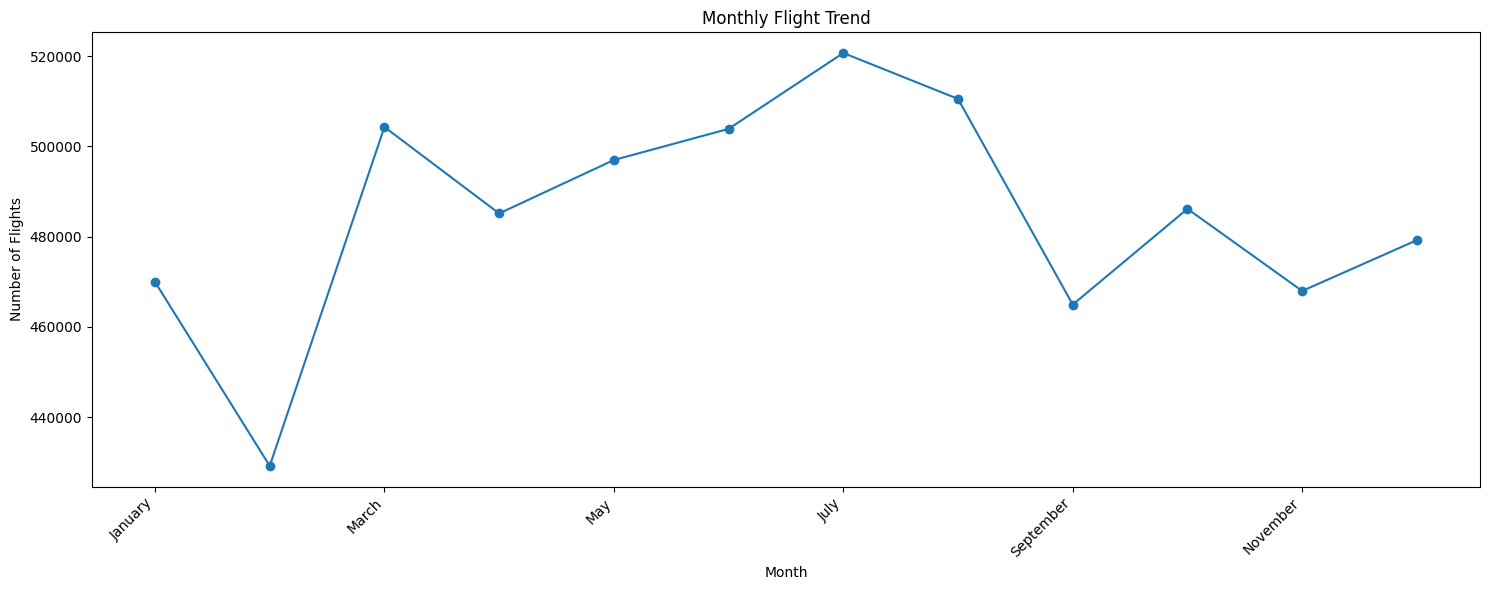

In [7]:
df['DATE'] = pd.to_datetime(df['DATE'])
df['MONTH_NAME'] = df['DATE'].dt.month_name()
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
df['MONTH_NAME'] = pd.Categorical(df['MONTH_NAME'], categories=month_order, ordered=True)

plt.figure(figsize=(15, 6))
ax = df.groupby('MONTH_NAME', observed=False).size().plot(kind='line', marker='o')
plt.title("Monthly Flight Trend")
plt.xlabel("Month")
plt.ylabel("Number of Flights")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

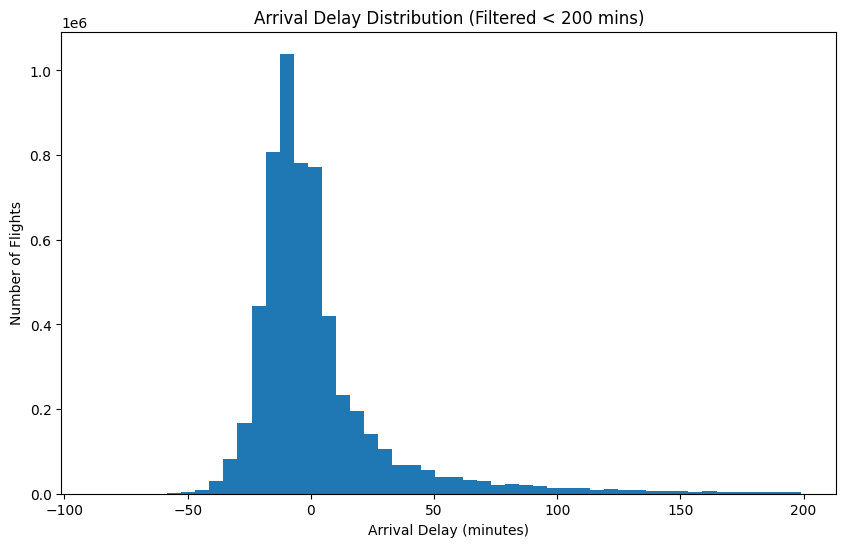

In [8]:
import matplotlib.pyplot as plt

plt.clf()
plt.figure(figsize=(10,6))
filtered_df = df[df['ARRIVAL_DELAY'] < 200]
plt.hist(filtered_df['ARRIVAL_DELAY'], bins=50)

plt.xlabel("Arrival Delay (minutes)")
plt.ylabel("Number of Flights")
plt.title("Arrival Delay Distribution (Filtered < 200 mins)")

plt.show()

In [10]:
def categorize_time(hour):
    if 0 <= hour < 6:
        return "Late Night"
    elif 6 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 18:
        return "Afternoon"
    else:
        return "Evening"

df['TIME_OF_DAY'] = df['DEPARTURE_HOUR'].apply(categorize_time)

time_of_day_order = ['Late Night', 'Morning', 'Afternoon', 'Evening']
df['TIME_OF_DAY'] = pd.Categorical(df['TIME_OF_DAY'], categories=time_of_day_order, ordered=True)

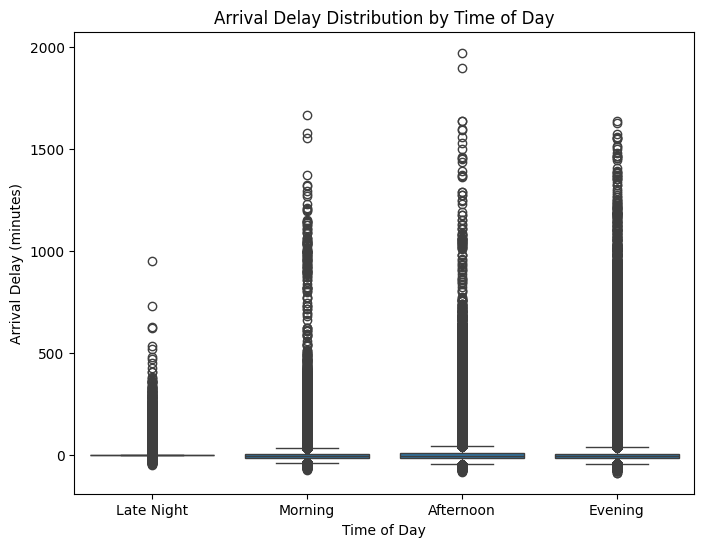

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.boxplot(
    x='TIME_OF_DAY',
    y='ARRIVAL_DELAY',
    data=df
)

plt.title("Arrival Delay Distribution by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Arrival Delay (minutes)")
plt.show()

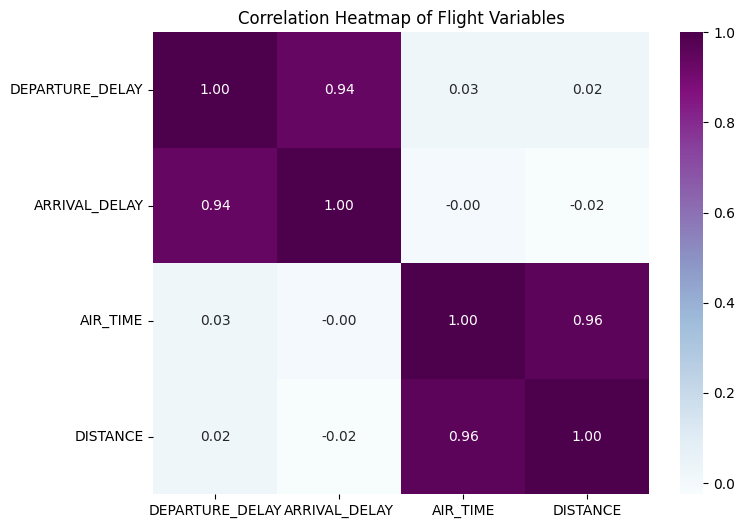

In [12]:
numeric_cols = [
    'DEPARTURE_DELAY',
    'ARRIVAL_DELAY',
    'AIR_TIME',
    'DISTANCE'
]

corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='BuPu',
    fmt=".2f"
)

plt.title("Correlation Heatmap of Flight Variables")
plt.show()

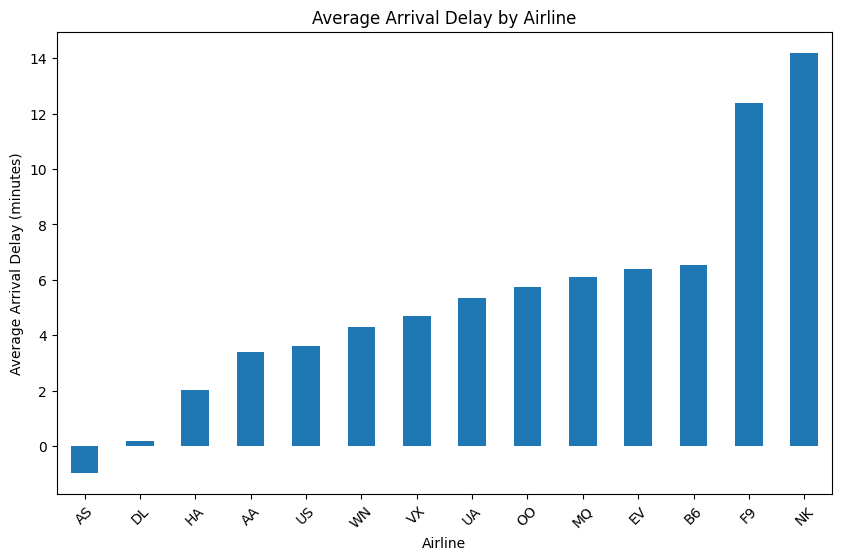

In [13]:
airline_delay = df.groupby('AIRLINE')['ARRIVAL_DELAY'].mean().sort_values()
plt.figure(figsize=(10,6))

airline_delay.plot(kind='bar')

plt.title("Average Arrival Delay by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Arrival Delay (minutes)")
plt.xticks(rotation=45)
plt.show()

In [14]:
df['DATE'] = pd.to_datetime(df['DATE'])
df['DAY_NAME'] = df['DATE'].dt.day_name()

In [15]:
day_order = ['Monday', 'Tuesday', 'Wednesday',
             'Thursday', 'Friday', 'Saturday', 'Sunday']

df['DAY_NAME'] = pd.Categorical(df['DAY_NAME'],
                                categories=day_order,
                                ordered=True)

In [16]:
day_delay = df.groupby('DAY_NAME')['ARRIVAL_DELAY'].mean()

/tmp/ipykernel_1274/4125664090.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_delay = df.groupby('DAY_NAME')['ARRIVAL_DELAY'].mean()


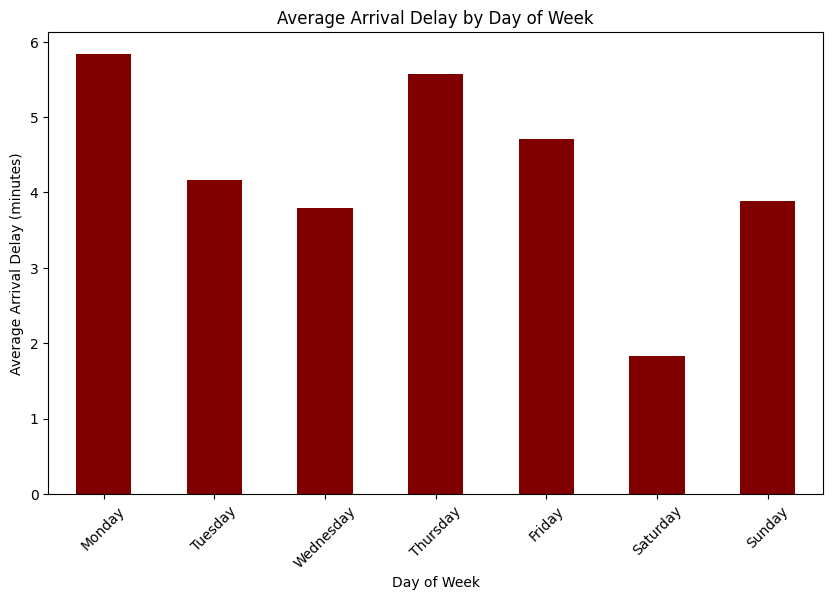

In [17]:
plt.figure(figsize=(10,6))

day_delay.plot(kind='bar', color='maroon')

plt.title("Average Arrival Delay by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Arrival Delay (minutes)")
plt.xticks(rotation=45)
plt.show()

In [18]:
delay_causes = df[[
    'AIRLINE_DELAY',
    'WEATHER_DELAY',
    'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY',
    'LATE_AIRCRAFT_DELAY'
]].sum()
delay_df = delay_causes.reset_index()
delay_df.columns = ['Delay_Type', 'Total_Delay']

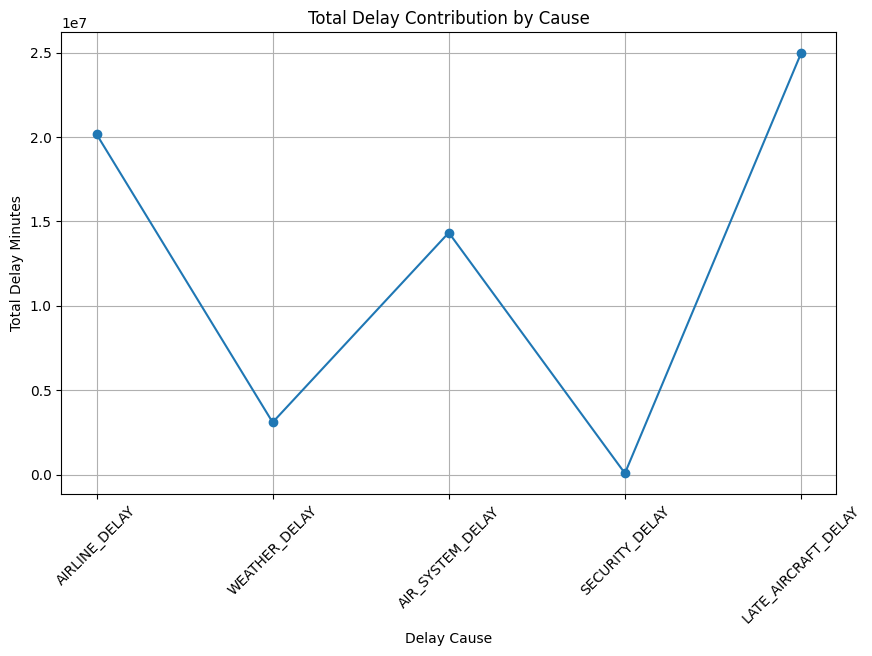

In [19]:
plt.figure(figsize=(10,6))
plt.plot(delay_df['Delay_Type'],
         delay_df['Total_Delay'],
         marker='o')

plt.title("Total Delay Contribution by Cause")
plt.xlabel("Delay Cause")
plt.ylabel("Total Delay Minutes")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

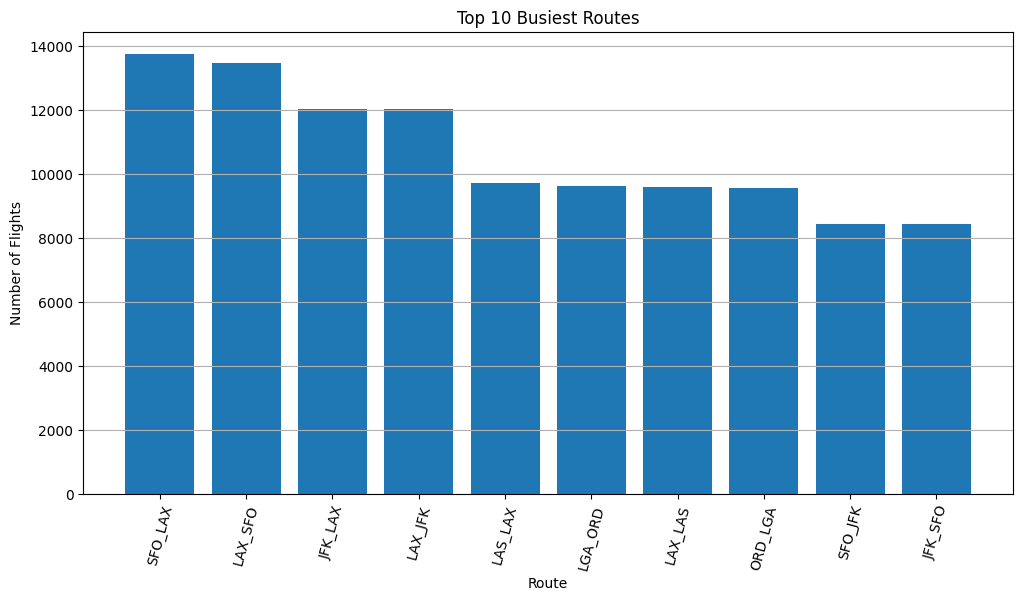

In [20]:
route_counts = df['ROUTE'].value_counts().head(10)
plt.figure(figsize=(12,6))

plt.bar(route_counts.index, route_counts.values)

plt.title("Top 10 Busiest Routes")
plt.xlabel("Route")
plt.ylabel("Number of Flights")
plt.xticks(rotation=75)
plt.grid(axis='y')


plt.show()

In [21]:
display(route_counts)

,count
ROUTE,
SFO_LAX,13744
LAX_SFO,13457
JFK_LAX,12016
LAX_JFK,12015
LAS_LAX,9715
LGA_ORD,9639
LAX_LAS,9594
ORD_LGA,9575
SFO_JFK,8440


In [22]:
df['ORIGIN_AIRPORT'] = df['ROUTE'].apply(lambda x: x.split('_')[0])
display(df.head())

,YEAR,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_DELAY,TAXI_OUT,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,...,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,DATE,TOTAL_DELAY,DEPARTURE_HOUR,ROUTE,MONTH_NAME,TIME_OF_DAY,DAY_NAME,ORIGIN_AIRPORT
0,2015,4,AS,98,5,-11.0,21.0,205.0,194.0,169.0,...,0.0,0.0,2015-01-01,0.0,23,ANC_SEA,January,Evening,Thursday,ANC
1,2015,4,AA,2336,10,-8.0,12.0,280.0,279.0,263.0,...,0.0,0.0,2015-01-01,0.0,2,LAX_PBI,January,Late Night,Thursday,LAX
2,2015,4,US,840,20,-2.0,16.0,286.0,293.0,266.0,...,0.0,0.0,2015-01-01,0.0,18,SFO_CLT,January,Evening,Thursday,SFO
3,2015,4,AA,258,20,-5.0,15.0,285.0,281.0,258.0,...,0.0,0.0,2015-01-01,0.0,15,LAX_MIA,January,Afternoon,Thursday,LAX
4,2015,4,AS,135,25,-1.0,11.0,235.0,215.0,199.0,...,0.0,0.0,2015-01-01,0.0,24,SEA_ANC,January,Evening,Thursday,SEA


In [23]:
top_airports = df['ORIGIN_AIRPORT'].value_counts().head(10).index
airport_delay = (
    df[df['ORIGIN_AIRPORT'].isin(top_airports)]
    .groupby('ORIGIN_AIRPORT')['ARRIVAL_DELAY']
    .mean()
    .sort_values(ascending=False)
)

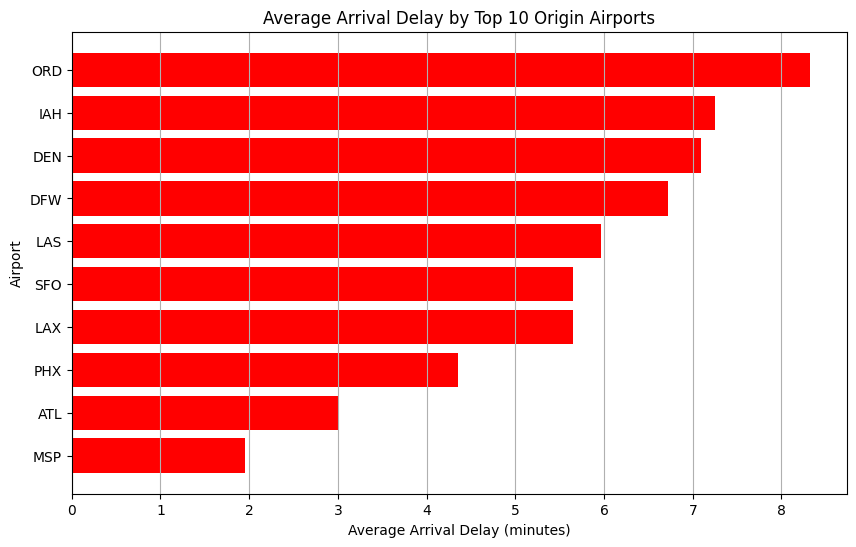

In [24]:
plt.figure(figsize=(10,6))

plt.barh(airport_delay.index, airport_delay.values, color='red')

plt.title("Average Arrival Delay by Top 10 Origin Airports")
plt.xlabel("Average Arrival Delay (minutes)")
plt.ylabel("Airport")
plt.gca().invert_yaxis()

plt.grid(axis='x')
plt.show()

/tmp/ipykernel_1274/3633772503.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delay_time = df.groupby('TIME_OF_DAY')[[


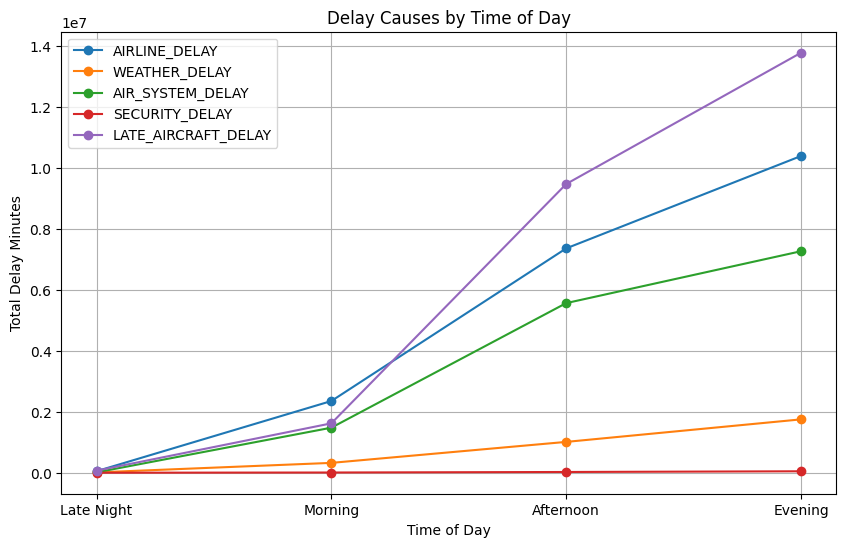

In [25]:
delay_time = df.groupby('TIME_OF_DAY')[[
    'AIRLINE_DELAY',
    'WEATHER_DELAY',
    'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY',
    'LATE_AIRCRAFT_DELAY'
]].sum()
plt.figure(figsize=(10,6))

for column in delay_time.columns:
    plt.plot(delay_time.index, delay_time[column], marker='o', label=column)

plt.title("Delay Causes by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Total Delay Minutes")
plt.legend()
plt.grid(True)

plt.show()

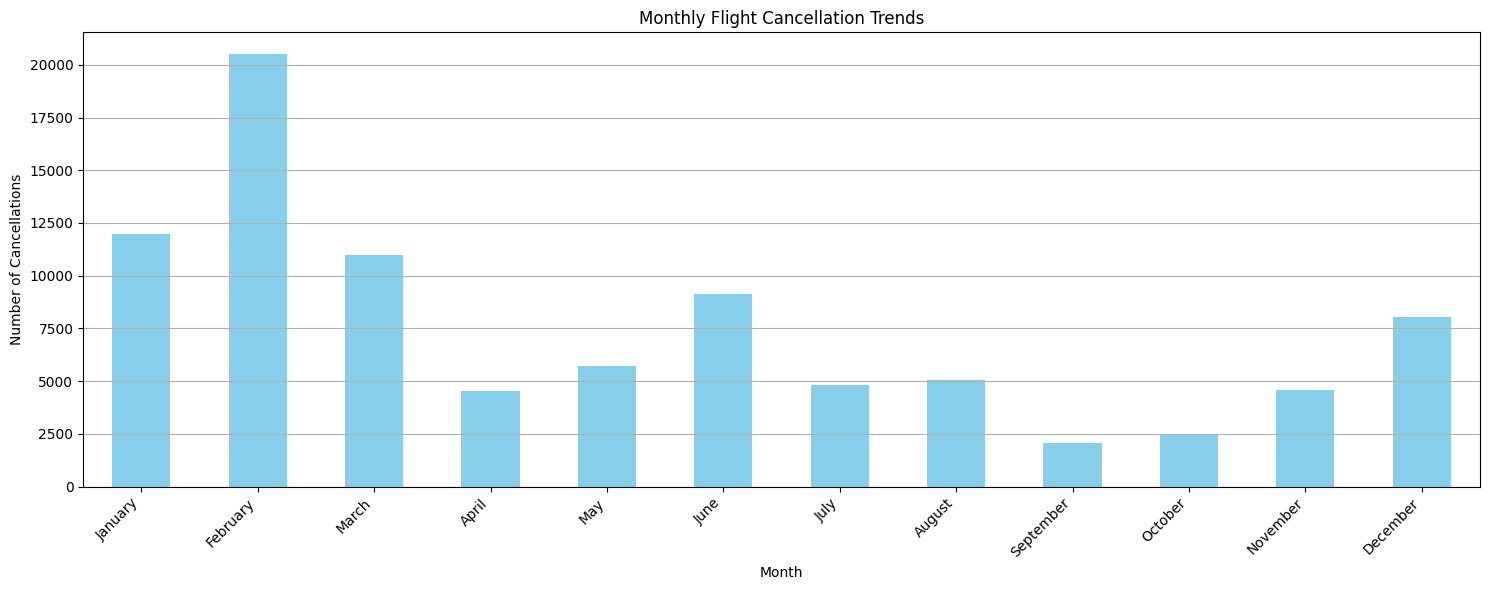

In [26]:
monthly_cancellations = df.groupby('MONTH_NAME', observed=False)['CANCELLED'].sum()

plt.figure(figsize=(15, 6))
monthly_cancellations.plot(kind='bar', color='skyblue')
plt.title("Monthly Flight Cancellation Trends")
plt.xlabel("Month")
plt.ylabel("Number of Cancellations")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### Cancellation Types Analysis

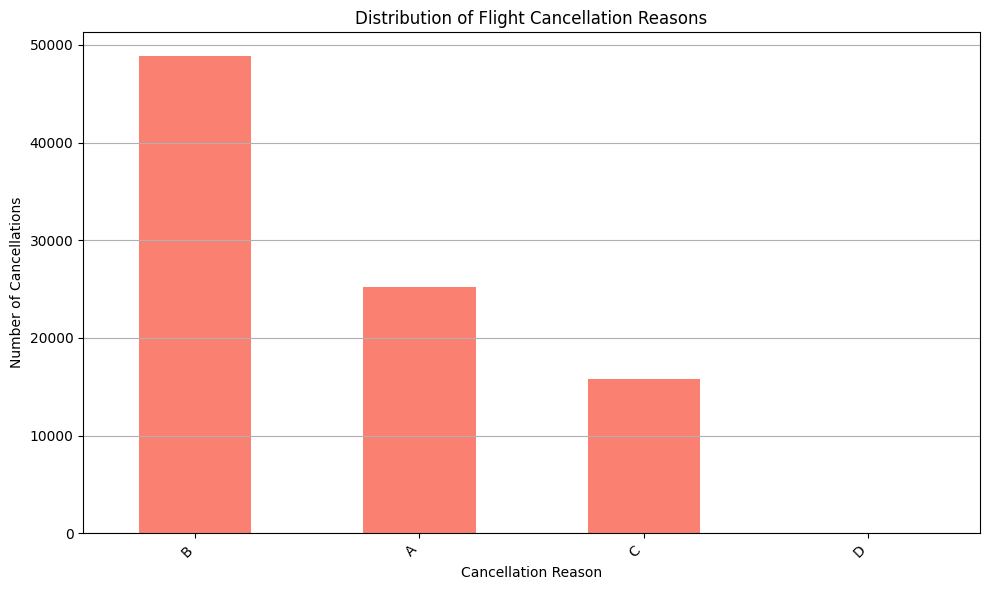

In [27]:
# Filter for cancelled flights
cancelled_flights_df = df[df['CANCELLED'] == 1]

# Get the counts of each cancellation reason
cancellation_reasons = cancelled_flights_df['CANCELLATION_REASON'].value_counts()

plt.figure(figsize=(10, 6))
cancellation_reasons.plot(kind='bar', color='salmon')
plt.title("Distribution of Flight Cancellation Reasons")
plt.xlabel("Cancellation Reason")
plt.ylabel("Number of Cancellations")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

The `CANCELLATION_REASON` column typically uses codes:  
'A' - Airline/Carrier  
'B' - Weather  
'C' - National Air System (NAS)  
'D' - Security

### Monthly Average Arrival Delay

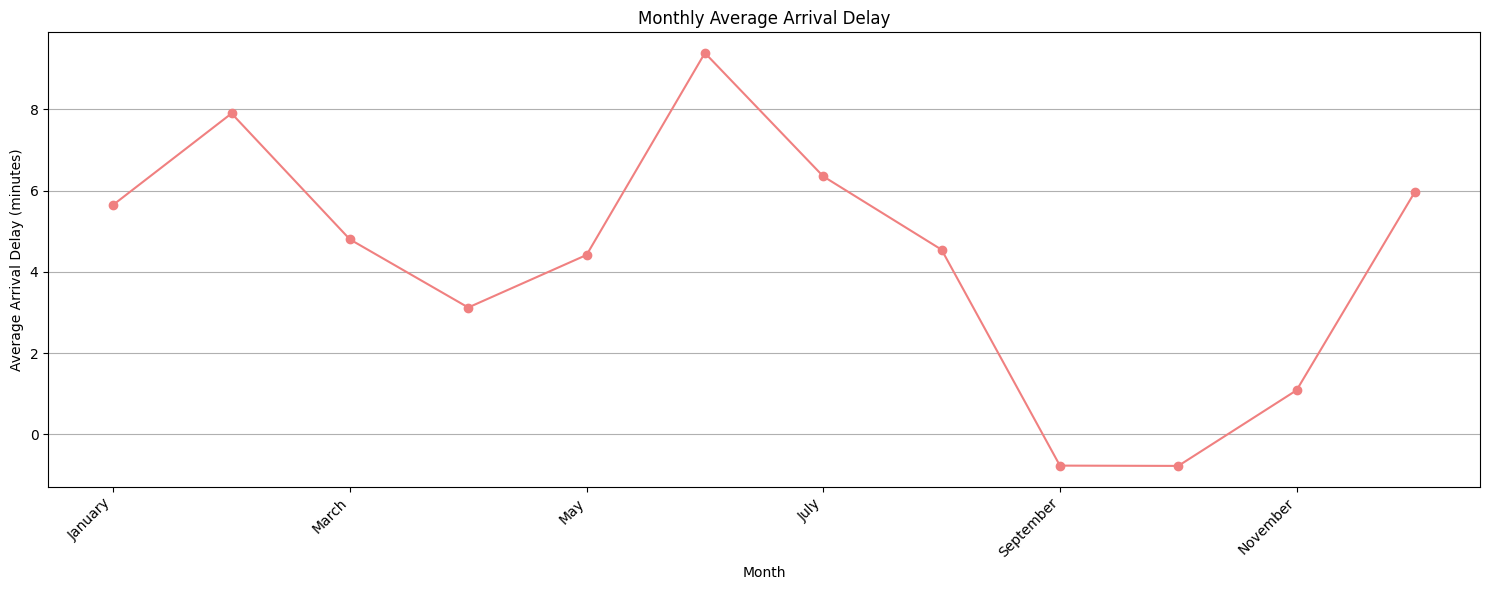

In [28]:
monthly_average_delay = df.groupby('MONTH_NAME', observed=False)['ARRIVAL_DELAY'].mean()

plt.figure(figsize=(15, 6))
monthly_average_delay.plot(kind='line', marker='o', color='lightcoral')
plt.title("Monthly Average Arrival Delay")
plt.xlabel("Month")
plt.ylabel("Average Arrival Delay (minutes)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### Analyzing Holiday Impact in Winter Months

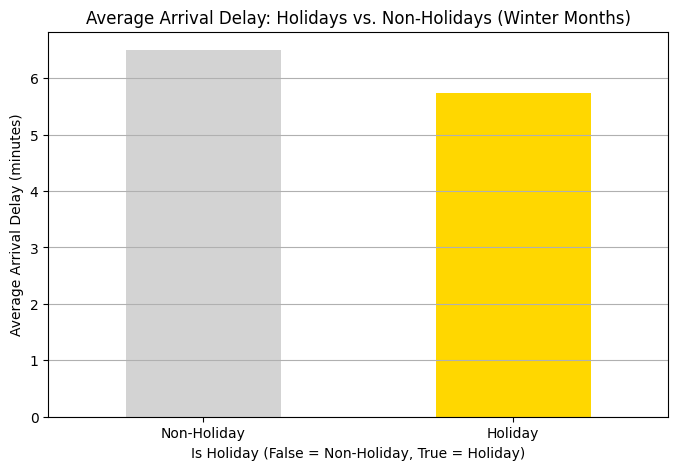

,ARRIVAL_DELAY
is_holiday,
False,6.497138
True,5.734257


In [29]:
from pandas.tseries.holiday import USFederalHolidayCalendar

# Define winter months
winter_months = ['December', 'January', 'February']

# Create a calendar for US federal holidays
cal = USFederalHolidayCalendar()
holidays = cal.holidays(start=df['DATE'].min(), end=df['DATE'].max())

# Create an 'is_holiday' column
df['is_holiday'] = df['DATE'].isin(holidays)

# Filter for winter months and then group by holiday status
winter_df = df[df['MONTH_NAME'].isin(winter_months)]
holiday_delay_winter = winter_df.groupby('is_holiday')['ARRIVAL_DELAY'].mean()

plt.figure(figsize=(8, 5))
holiday_delay_winter.plot(kind='bar', color=['lightgray', 'gold'])
plt.title("Average Arrival Delay: Holidays vs. Non-Holidays (Winter Months)")
plt.xlabel("Is Holiday (False = Non-Holiday, True = Holiday)")
plt.ylabel("Average Arrival Delay (minutes)")
plt.xticks(ticks=[0, 1], labels=['Non-Holiday', 'Holiday'], rotation=0)
plt.grid(axis='y')
plt.show()

display(holiday_delay_winter)

This plot shows the average arrival delay during winter months, comparing flights on federal holidays to those on non-holidays. If you want to analyze specific holidays or custom holidays, we can adjust the `holidays` list.

### Delay Causes Heatmap by Top 10 Origin Airports

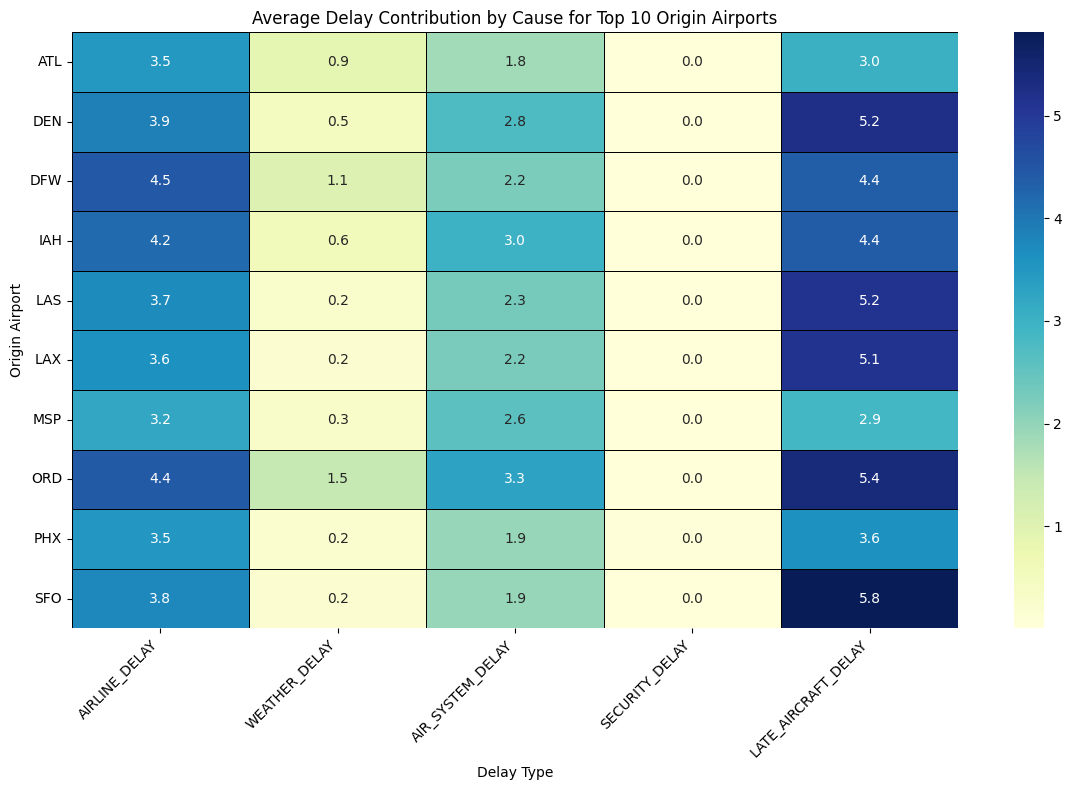

In [30]:
delay_cols = [
    'AIRLINE_DELAY',
    'WEATHER_DELAY',
    'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY',
    'LATE_AIRCRAFT_DELAY'
]

# Get top 10 origin airports (already computed as 'top_airports')
# Filter df for these airports
airport_delay_causes = (
    df[df['ORIGIN_AIRPORT'].isin(top_airports)]
    .groupby('ORIGIN_AIRPORT')[delay_cols]
    .mean()
)

plt.figure(figsize=(12, 8))
sns.heatmap(
    airport_delay_causes,
    annot=True,
    cmap='YlGnBu',
    fmt=".1f",
    linewidths=.5,
    linecolor='black'
)
plt.title("Average Delay Contribution by Cause for Top 10 Origin Airports")
plt.xlabel("Delay Type")
plt.ylabel("Origin Airport")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Delay Causes Heatmap by Top 10 Busiest Routes

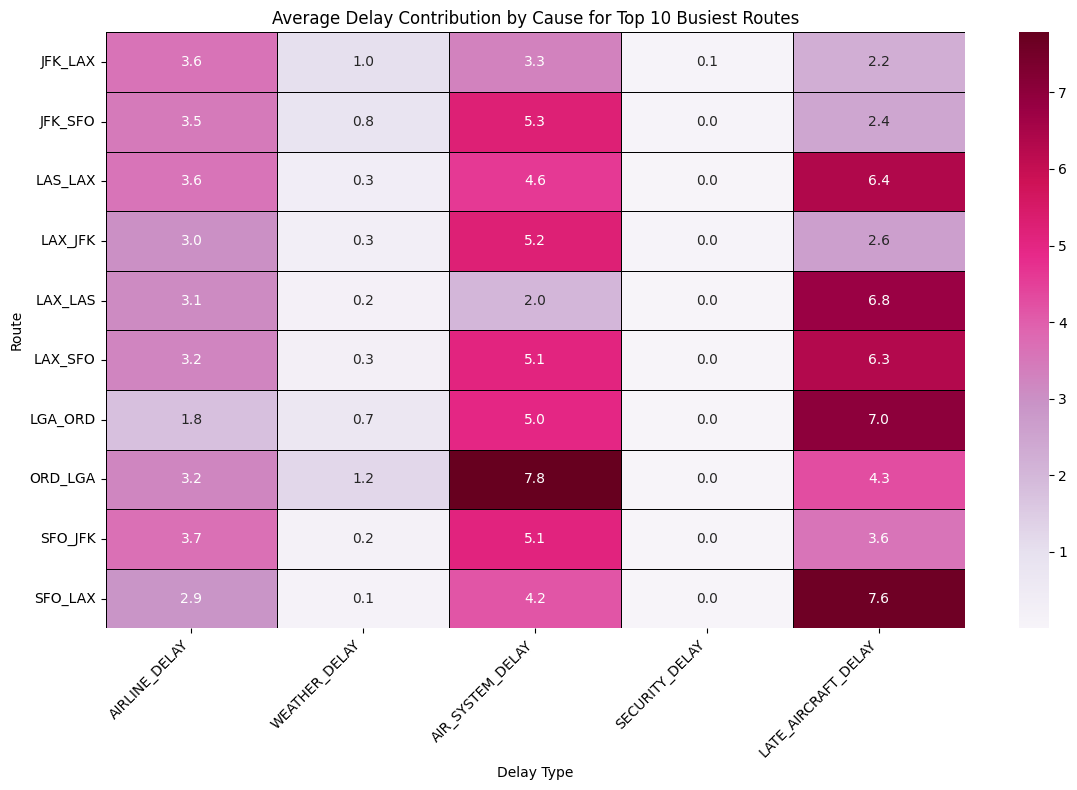

In [31]:
delay_cols = [
    'AIRLINE_DELAY',
    'WEATHER_DELAY',
    'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY',
    'LATE_AIRCRAFT_DELAY'
]

# Get top 10 busiest routes (already computed as 'route_counts')
# Filter df for these routes
route_delay_causes = (
    df[df['ROUTE'].isin(route_counts.index)]
    .groupby('ROUTE')[delay_cols]
    .mean()
)

plt.figure(figsize=(12, 8))
sns.heatmap(
    route_delay_causes,
    annot=True,
    cmap='PuRd',
    fmt=".1f",
    linewidths=.5,
    linecolor='black'
)
plt.title("Average Delay Contribution by Cause for Top 10 Busiest Routes")
plt.xlabel("Delay Type")
plt.ylabel("Route")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()